# Plotting

bindcurve plotting is Axes-first: create your own Matplotlib `ax`, then let bindcurve draw observations, fitted curves, confidence bands, asymptotes, curve points, and residuals.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import bindcurve as bc

rng = np.random.default_rng(123)

## Generate a small synthetic IC50 dataset

In [8]:
data_all = bc.DoseResponseData.from_csv(
    "tutorial_data/synthetic/direct_binding_wide.csv", 
    format="wide",
)

data = bc.DoseResponseData(
    data_all.table[data_all.table['compound_id'] == 'direct_cmpd_1'],
)

results = bc.fit(
    data, 
    model='ic50', 
    fixed={'ymin': 0.0, 'ymax': 100.0}
)
data

DoseResponseData(table=       compound_id  concentration experiment_id replicate_id  response
0    direct_cmpd_1         0.0001         exp_1   response_1     0.040
1    direct_cmpd_1         0.0003         exp_1   response_1     4.102
2    direct_cmpd_1         0.0010         exp_1   response_1     2.146
3    direct_cmpd_1         0.0030         exp_1   response_1     6.672
4    direct_cmpd_1         0.0100         exp_1   response_1    23.651
..             ...            ...           ...          ...       ...
424  direct_cmpd_1         0.1000         exp_3   response_5    74.175
425  direct_cmpd_1         0.3000         exp_3   response_5    89.499
426  direct_cmpd_1         1.0000         exp_3   response_5    98.018
427  direct_cmpd_1         3.0000         exp_3   response_5   101.321
428  direct_cmpd_1        10.0000         exp_3   response_5   103.493

[165 rows x 5 columns], metadata={})

## Observations and fits as separate layers

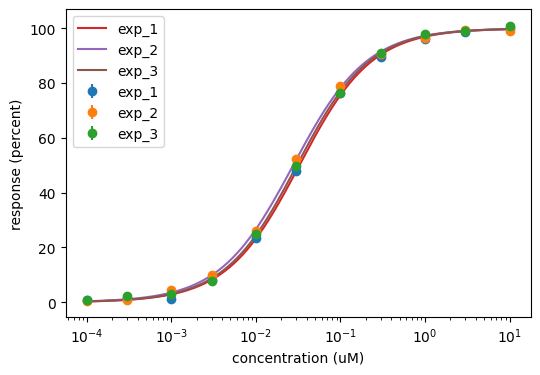

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
bc.plot_observations(data, ax=ax)
bc.plot_fits(data, results, ax=ax)
ax.legend()
plt.show()

## One-call plot with confidence bands and annotations

AttributeError: Line2D.set() got an unexpected keyword argument 'confidence_band'

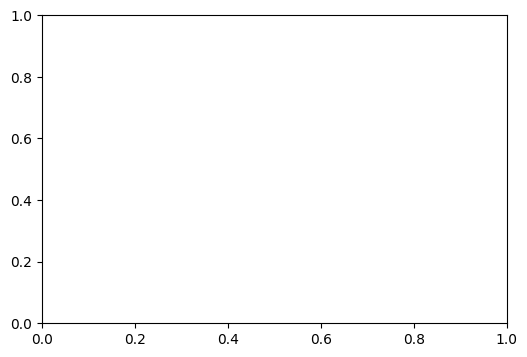

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
bc.plot_fits(
    data,
    results,
    ax=ax,
    confidence_band=True,
)
bc.plot_asymptotes(data, results, ax=ax, experiments=['exp1'])
bc.plot_curve_points(data, results, ax=ax, experiments=['exp1'], points=[(1.5, 'nominal IC50')])
ax.legend()
plt.show()

## Fully composed plot

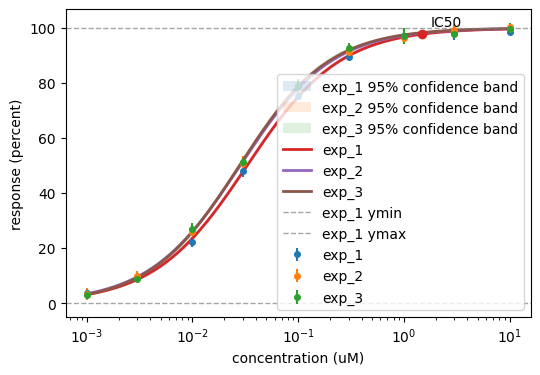

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
bc.plot_observations(data, ax=ax, error='sd', markersize=4)
bc.plot_confidence_bands(data, results, ax=ax, alpha=0.15)
bc.plot_fits(data, results, ax=ax, curve_width=2)
bc.plot_asymptotes(data, results, ax=ax, experiments=['exp_1'], color='gray')
bc.plot_curve_points(data, results, ax=ax, experiments=['exp_1'], points=[(1.5, 'IC50')])
ax.legend()
plt.show()

## Residual plot

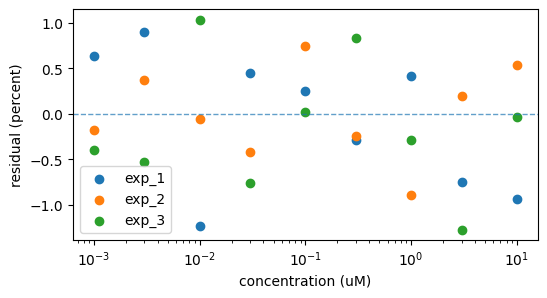

In [ ]:
fig, ax = plt.subplots(figsize=(6, 3))
bc.plot_residuals(data, results, ax=ax)
ax.legend()
plt.show()

## Aggregated plotting with `plot_compounds()`

If you have multiple experiments per compound but want a single summary plot, use `plot_compounds()`. It draws grand-mean observations across experiments plus a plotting-only master fit. Inter-experiment uncertainty is shown with SD/SEM error bars on those grand means, and the markers plus master curve share one label and color by default.

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))

# This will compute grand-mean observations across exp_1, exp_2, and exp_3
bc.plot_compounds(
    data_all, 
    results, 
    compounds="direct_cmpd_1", 
    ax=ax
)
ax.legend()
plt.show()